# Model building and Testing

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression as lr
from sklearn.tree import DecisionTreeClassifier as dt
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier as knn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

### Pre requisites

In [2]:
data = pd.read_csv("breast+cancer+wisconsin+diagnostic\data_resampled.csv")
data.head()

,Unnamed: 0,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,0,895100,1,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,...,25.30,31.86,171.10,1938.0,0.1592,0.4492,0.53440,0.26850,0.5558,0.10240
1,1,905686,0,11.89,21.17,76.39,433.8,0.09773,0.08120,0.02555,...,13.05,27.21,85.09,522.9,0.1426,0.2187,0.11640,0.08263,0.3075,0.07351
2,2,884180,1,19.40,23.50,129.10,1155.0,0.10270,0.15580,0.20490,...,21.65,30.53,144.90,1417.0,0.1463,0.2968,0.34580,0.15640,0.2920,0.07614
3,3,859983,1,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,...,16.57,20.86,110.30,812.4,0.1411,0.3542,0.27790,0.13830,0.2589,0.10300
4,4,871122,0,12.06,12.74,76.84,448.6,0.09311,0.05241,0.01972,...,13.14,18.41,84.08,532.8,0.1275,0.1232,0.08636,0.07025,0.2514,0.07898


In [3]:
data = data.drop('Unnamed: 0', axis=1)
data.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,895100,1,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,0.15040,...,25.30,31.86,171.10,1938.0,0.1592,0.4492,0.53440,0.26850,0.5558,0.10240
1,905686,0,11.89,21.17,76.39,433.8,0.09773,0.08120,0.02555,0.02179,...,13.05,27.21,85.09,522.9,0.1426,0.2187,0.11640,0.08263,0.3075,0.07351
2,884180,1,19.40,23.50,129.10,1155.0,0.10270,0.15580,0.20490,0.08886,...,21.65,30.53,144.90,1417.0,0.1463,0.2968,0.34580,0.15640,0.2920,0.07614
3,859983,1,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,...,16.57,20.86,110.30,812.4,0.1411,0.3542,0.27790,0.13830,0.2589,0.10300
4,871122,0,12.06,12.74,76.84,448.6,0.09311,0.05241,0.01972,0.01963,...,13.14,18.41,84.08,532.8,0.1275,0.1232,0.08636,0.07025,0.2514,0.07898


In [4]:
data.shape

(422, 27)

### Train Test Split

In [5]:
X = data.drop(columns=['Diagnosis', 'ID'])
y = data['Diagnosis']
X.head() 

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave points1,symmetry1,radius2,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,0.15040,0.2569,0.5702,...,25.30,31.86,171.10,1938.0,0.1592,0.4492,0.53440,0.26850,0.5558,0.10240
1,11.89,21.17,76.39,433.8,0.09773,0.08120,0.02555,0.02179,0.2019,0.2747,...,13.05,27.21,85.09,522.9,0.1426,0.2187,0.11640,0.08263,0.3075,0.07351
2,19.40,23.50,129.10,1155.0,0.10270,0.15580,0.20490,0.08886,0.1978,0.5243,...,21.65,30.53,144.90,1417.0,0.1463,0.2968,0.34580,0.15640,0.2920,0.07614
3,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.2787,...,16.57,20.86,110.30,812.4,0.1411,0.3542,0.27790,0.13830,0.2589,0.10300
4,12.06,12.74,76.84,448.6,0.09311,0.05241,0.01972,0.01963,0.1590,0.1822,...,13.14,18.41,84.08,532.8,0.1275,0.1232,0.08636,0.07025,0.2514,0.07898


In [6]:
X_Train, X_Test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Model Fitting and testing

In [7]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from xgboost import XGBClassifier

In [8]:
models = {
    'Logistic Regression' : lr(),
    'Descision Tree' : dt(),
    'Random Forest' : rf(),
    'SVC' : SVC(),
    'XGB Classifier' : XGBClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_Train, y_train)
    y_pred = model.predict(X_Test)
    results.append({
        'Model' : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, pos_label=1),
        'Recall' : recall_score(y_test, y_pred, pos_label=1),
        'F1 Score' : f1_score(y_test, y_pred, pos_label=1)
    })

scoreboard = pd.DataFrame(results)
scoreboard

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.924528,0.957447,0.882353,0.918367
1,Descision Tree,0.971698,0.980000,0.960784,0.970297
2,Random Forest,0.943396,0.959184,0.921569,0.940000
3,SVC,0.867925,0.911111,0.803922,0.854167
4,XGB Classifier,0.962264,0.979592,0.941176,0.960000


XGBoost and Descision Tree Classifers had the best F1 score. So they will now be used during hyperparameter training

### Hyperparameter training

In [9]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

In [10]:
def objective_dt(trial):
    params = {
        'max_depth' : trial.suggest_int('max_depth', 2, 50),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 50 ),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 2, 50),
        'min_weight_fraction_leaf' : trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5),
        'max_features' : trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = dt(**params, random_state=42)
    score = cross_val_score(model, X_Train, y_train, cv=5, scoring=make_scorer(f1_score, pos_label=1)).mean()
    return score




In [11]:
import optuna.visualization as vis



In [12]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_dt, n_trials=100)

op_his = vis.plot_optimization_history(study)
op_his.show()
par_imp = vis.plot_param_importances(study)
par_imp.show()

best_score_dt = study.best_value 
best_params_dt = study.best_params    

print("Best recall:", best_score_dt)
print("Best parameters:", best_params_dt)


[I 2026-03-28 16:54:26,252] A new study created in memory with name: no-name-976e8992-a5cb-4789-8524-b6a67f3961b6
[I 2026-03-28 16:54:26,277] Trial 0 finished with value: 0.8844354931124474 and parameters: {'max_depth': 17, 'min_samples_split': 15, 'min_samples_leaf': 22, 'min_weight_fraction_leaf': 0.37861125376329635, 'max_features': None}. Best is trial 0 with value: 0.8844354931124474.
[I 2026-03-28 16:54:26,298] Trial 1 finished with value: 0.9029942100909845 and parameters: {'max_depth': 49, 'min_samples_split': 46, 'min_samples_leaf': 32, 'min_weight_fraction_leaf': 0.20940137523438934, 'max_features': 'log2'}. Best is trial 1 with value: 0.9029942100909845.
[I 2026-03-28 16:54:26,317] Trial 2 finished with value: 0.8844354931124474 and parameters: {'max_depth': 35, 'min_samples_split': 4, 'min_samples_leaf': 32, 'min_weight_fraction_leaf': 0.4495562335697166, 'max_features': None}. Best is trial 1 with value: 0.9029942100909845.
[I 2026-03-28 16:54:26,339] Trial 3 finished with

Best recall: 0.9090693181002898
Best parameters: {'max_depth': 8, 'min_samples_split': 50, 'min_samples_leaf': 32, 'min_weight_fraction_leaf': 0.49381340380691063, 'max_features': 'sqrt'}


In [13]:
model_dt = dt(**best_params_dt)
model_dt.fit(X_Train, y_train)

y_pred = model_dt.predict(X_Test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        55
           1       0.96      0.86      0.91        51

    accuracy                           0.92       106
   macro avg       0.92      0.91      0.91       106
weighted avg       0.92      0.92      0.91       106



In [14]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000),
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    score = cross_val_score(model, X_Train, y_train, cv=5, scoring=make_scorer(f1_score, pos_label=1)).mean()
    return score


In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=100)

op_his = vis.plot_optimization_history(study)
op_his.show()
par_imp = vis.plot_param_importances(study)
par_imp.show()

best_score_xgb = study.best_value 
best_params_xgb = study.best_params    

print("Best recall:", best_score_xgb)
print("Best parameters:", best_params_xgb)

[I 2026-03-28 16:54:29,240] A new study created in memory with name: no-name-8c0512b2-7b64-49b5-9364-df1c898a9630
[I 2026-03-28 16:54:30,890] Trial 0 finished with value: 0.9593053989021731 and parameters: {'n_estimators': 1617, 'max_depth': 18, 'learning_rate': 0.22577364941898134, 'subsample': 0.6378200975105413, 'colsample_bytree': 0.879131044656539, 'gamma': 0.012144414630446687, 'reg_alpha': 1.5196366692035497, 'reg_lambda': 3.5714639849821115}. Best is trial 0 with value: 0.9593053989021731.
[I 2026-03-28 16:54:33,130] Trial 1 finished with value: 0.94430586197451 and parameters: {'n_estimators': 2265, 'max_depth': 5, 'learning_rate': 0.057075581713362515, 'subsample': 0.8923527111289461, 'colsample_bytree': 0.978049731079851, 'gamma': 1.315105626790084, 'reg_alpha': 0.76342093119246, 'reg_lambda': 4.700670973483161}. Best is trial 0 with value: 0.9593053989021731.
[I 2026-03-28 16:54:34,426] Trial 2 finished with value: 0.9535203381917393 and parameters: {'n_estimators': 1092, '

Best recall: 0.9779714640198511
Best parameters: {'n_estimators': 848, 'max_depth': 14, 'learning_rate': 0.2262859834955304, 'subsample': 0.5603817755490094, 'colsample_bytree': 0.562944140900348, 'gamma': 0.1303755112488854, 'reg_alpha': 0.015341439048385752, 'reg_lambda': 3.808980729747365}


In [16]:
from sklearn.metrics import classification_report

model_xgb = XGBClassifier(**best_params_xgb)
model_xgb.fit(X_Train, y_train)

y_pred = model_xgb.predict(X_Test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96        55
           1       0.98      0.94      0.96        51

    accuracy                           0.96       106
   macro avg       0.96      0.96      0.96       106
weighted avg       0.96      0.96      0.96       106



In [17]:
import shap

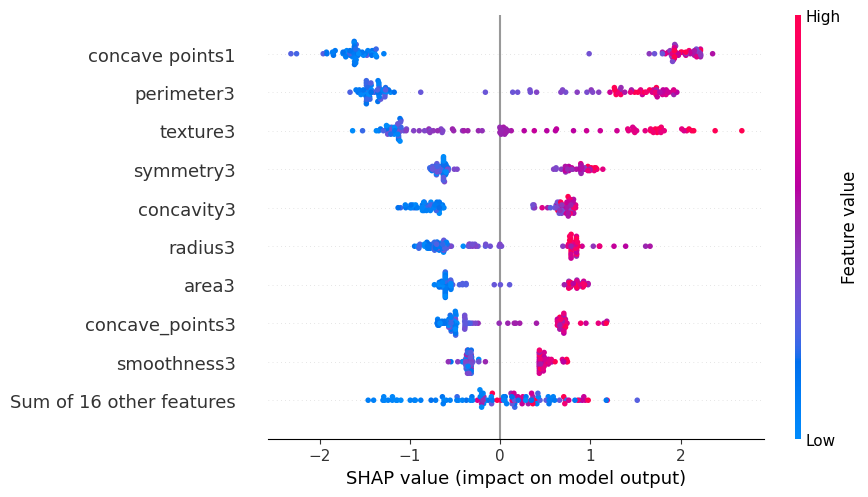

In [19]:
explainer = shap.Explainer(model, X_Test)
shap_values = explainer(X_Test)

shap_xgb = shap.plots.beeswarm(shap_values)